#Import modules

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

#Data

In [3]:
rna = pd.read_csv('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/transfer_data_combination.csv', index_col = 0)
rna

,ENSG00000164930,ENSG00000197594,ENSG00000124226,ENSG00000159184,ENSG00000198668,ENSG00000179142,ENSG00000007350,ENSG00000129744,ENSG00000170035,ENSG00000170950,...,ENSG00000034677,ENSG00000135241,ENSG00000083123,ENSG00000136247,ENSG00000095303,ENSG00000130717,ENSG00000122643,ENSG00000141959,ENSG00000184307,ENSG00000115425
MSKC-00397,14.529881,9.240603,137.021485,1.367006,194.934404,0.000000,0.146082,0.115708,67.298137,0.000000,...,40.706703,18.973572,6.662711,64.911143,43.204901,25.409572,58.497425,103.255543,1.397247,9.702442
MSKC-00399,24.450902,6.571562,118.166876,0.041264,344.872173,0.000000,0.302495,0.000000,110.065381,0.000000,...,56.435361,30.334806,35.942656,102.512775,3.612696,55.110532,33.836278,138.506963,7.439917,55.062394
MSKC-00400,12.766091,0.371475,102.403094,0.000000,277.825765,0.000000,0.067137,0.066472,126.381236,0.000000,...,52.821845,26.818338,14.078094,155.775369,6.503317,57.705789,61.026194,194.356737,4.903670,56.886399
MSKC-00404,18.893303,5.938466,97.193476,0.157535,221.914215,0.000000,0.137483,0.054449,71.815138,0.047167,...,70.230232,16.186658,6.291991,48.576568,14.177906,29.507746,38.068482,83.490134,1.231318,10.698925
MSKC-00405,33.396663,9.647005,108.183866,4.507236,347.903477,0.000000,0.540485,0.285404,101.109437,0.000000,...,55.431652,19.275446,10.299446,72.113304,26.317369,30.146145,49.397786,154.065618,4.261025,12.890315
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PT-P44H,1.135020,0.125583,10.407573,0.000000,1056.421129,0.012623,0.010607,0.038140,2.114443,0.000000,...,3.360212,3.752738,0.473573,6.946527,0.873067,16.833178,1.938041,21.612059,9.216555,0.338641
PT-R55F,1.584404,0.116797,10.427795,0.000000,1249.603841,0.113716,0.051188,0.073625,1.437406,0.000000,...,3.937455,5.221783,0.548702,6.798857,0.827395,16.496770,1.631131,20.710282,10.968329,0.506843
PT-RN5K,1.645791,0.100308,11.193488,0.000000,415.265099,0.013185,0.080321,0.044817,0.932083,0.076597,...,3.070159,3.027389,0.492642,5.035513,0.751665,16.296053,0.879951,19.522703,7.480715,0.335969
PT-UTHO,1.466925,0.211382,15.217994,0.000000,1060.037352,0.052133,0.010951,0.029534,1.726350,0.000000,...,3.796485,3.587618,0.469935,7.235763,1.312534,19.503146,1.915177,21.660793,11.469005,0.605020


In [4]:
metabolites = pd.read_csv('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/metabolomics_log2.csv', index_col = 0)
metabolites = metabolites.T
metabolites

,"1,2-propanediol","1,5-anhydroglucitol (1,5-AG)",1-arachidonoyl-GPC (20:4n6),1-arachidonoyl-GPE (20:4n6),1-arachidonoyl-GPI (20:4),1-eicosatrienoylglycerophosphocholine (20:3),1-margaroylglycerophosphocholine (17:0),1-linoleoylglycerol (18:2),1-linoleoyl-GPC (18:2),1-linoleoylglycerophosphoethanolamine,...,malonate,metronidazole,N-carboxymethylalanine,N1-Methyl-4-pyridone-3-carboxamide,N6-methyladenosine,nicotinate ribonucleoside,norfluoxetine,palmitoleoyl ethanolamide,succinimide,thyroxine
DUKE-00651,21.037723,19.394321,17.671134,14.233610,14.384728,16.818972,15.262543,14.061858,18.733537,13.836203,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DUKE-00652,23.959087,19.044231,14.631118,16.423374,16.305192,13.493080,13.337998,16.244013,14.342457,14.410637,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DUKE-00653,20.682481,19.193116,15.608743,14.400485,15.299840,14.887658,14.486196,15.090475,16.891647,14.514168,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DUKE-00654,19.963768,19.653941,15.383235,15.369813,14.913759,14.578475,13.337998,14.576805,17.531595,16.108259,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DUKE-00657,19.677653,20.145794,17.854153,14.785590,14.445883,16.213699,13.337998,14.759995,19.931038,15.195652,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MSKC-00483,NaN,20.623605,20.772511,22.201466,23.203913,NaN,NaN,23.400548,21.974739,NaN,...,20.905649,19.987368,13.949308,18.857947,18.121721,15.876410,21.917796,14.204030,16.028156,13.218192
MSKC-00484,NaN,19.709740,21.012143,21.916148,21.409801,NaN,NaN,22.066585,23.908872,NaN,...,19.997085,19.987368,18.341589,15.813626,18.832340,15.876410,21.917796,14.081109,15.167041,13.218192
MSKC-00485,NaN,19.393769,20.316594,20.322285,20.074359,NaN,NaN,19.395849,21.530004,NaN,...,20.422488,19.987368,17.367652,19.865964,16.375009,18.547371,21.917796,13.940225,16.306077,13.218192
MSKC-00486,NaN,18.795282,19.099814,21.605296,22.077745,NaN,NaN,21.328106,20.474841,NaN,...,20.117567,19.987368,17.310323,19.386511,16.781328,15.876410,21.917796,13.940225,20.522298,13.218192


In [5]:
threshold = 0.2
nan_percentage = metabolites.isnull().mean()
filtered_metabolites = metabolites.loc[:, nan_percentage <= threshold]
metabolites = filtered_metabolites
metabolites

,"1,5-anhydroglucitol (1,5-AG)",1-arachidonoyl-GPC (20:4n6),1-arachidonoyl-GPE (20:4n6),1-arachidonoyl-GPI (20:4),1-linoleoylglycerol (18:2),1-linoleoyl-GPC (18:2),1-oleoylglycerol (1-monoolein),1-oleoyl-GPE (18:1),1-palmitoleoyl-GPC (16:1),1-palmitoylglycerol (1-monopalmitin),...,urea,uridine,valine,valylglycine,xanthine,xanthosine,3-phosphoglycerate,dehydroascorbate,pyruvate,phosphoenolpyruvate (PEP)
DUKE-00651,19.394321,17.671134,14.233610,14.384728,14.061858,18.733537,14.160222,17.035593,18.238785,16.193003,...,19.791208,17.280007,20.914748,13.103914,15.290542,11.141052,NaN,NaN,NaN,NaN
DUKE-00652,19.044231,14.631118,16.423374,16.305192,16.244013,14.342457,14.630229,17.097542,14.162099,16.343955,...,20.714696,17.931028,20.966490,11.180255,14.081160,15.169395,NaN,NaN,NaN,NaN
DUKE-00653,19.193116,15.608743,14.400485,15.299840,15.090475,16.891647,14.793942,16.787389,15.598227,16.307270,...,20.026746,17.416825,20.626487,12.483334,13.719496,10.940461,NaN,NaN,NaN,NaN
DUKE-00654,19.653941,15.383235,15.369813,14.913759,14.576805,17.531595,13.698657,17.498170,15.382139,14.735908,...,19.417532,17.333397,20.786484,12.785167,15.008995,11.457243,NaN,NaN,NaN,NaN
DUKE-00657,20.145794,17.854153,14.785590,14.445883,14.759995,19.931038,14.140832,16.189295,16.830153,13.092027,...,20.029593,18.298603,20.829264,12.072888,12.760453,10.473938,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MSKC-00483,20.623605,20.772511,22.201466,23.203913,23.400548,21.974739,23.832628,21.126642,15.528993,23.714071,...,23.642103,22.356899,26.906058,13.804900,20.249497,18.873510,21.795535,21.284580,19.835953,20.788527
MSKC-00484,19.709740,21.012143,21.916148,21.409801,22.066585,23.908872,22.744470,24.818447,19.777455,22.367748,...,23.335062,18.983131,28.243038,16.627670,19.755282,19.011004,22.483612,22.112696,17.565157,21.367133
MSKC-00485,19.393769,20.316594,20.322285,20.074359,19.395849,21.530004,21.115255,21.695953,17.689438,22.340078,...,24.068418,21.271504,28.150188,13.804900,21.861710,20.761065,20.709723,22.940596,19.620601,19.702365
MSKC-00486,18.795282,19.099814,21.605296,22.077745,21.328106,20.474841,22.967082,21.579612,16.366178,22.815021,...,24.338312,22.174396,28.327350,15.008651,21.947564,18.447479,20.908825,21.293467,17.466552,20.561626


#Log2 transformation

In [6]:
rna = rna.apply(lambda x: np.log2(x + 1))
rna.head(3)

,ENSG00000164930,ENSG00000197594,ENSG00000124226,ENSG00000159184,ENSG00000198668,ENSG00000179142,ENSG00000007350,ENSG00000129744,ENSG00000170035,ENSG00000170950,...,ENSG00000034677,ENSG00000135241,ENSG00000083123,ENSG00000136247,ENSG00000095303,ENSG00000130717,ENSG00000122643,ENSG00000141959,ENSG00000184307,ENSG00000115425
MSKC-00397,3.956975,3.356229,7.108749,1.243063,7.614227,0.0,0.196711,0.157960,6.093774,0.0,...,5.382207,4.320020,2.937855,6.042450,5.466134,4.722989,5.894755,6.703980,1.261379,3.419868
MSKC-00399,4.669645,2.920591,6.896839,0.058335,8.434095,0.0,0.381278,0.000000,6.795265,0.0,...,5.843867,4.969694,5.207216,6.693665,2.205610,5.810200,5.122519,7.124193,3.077229,5.808961
MSKC-00400,3.783047,0.455728,6.692136,0.000000,8.123220,0.0,0.093745,0.092846,6.993009,0.0,...,5.750120,4.797964,3.914382,7.292555,2.907529,5.875431,5.954806,7.609967,2.561612,5.855153


#Data shuffling

In [7]:
combined_data = pd.concat([rna, metabolites], axis=1)
shuffled_data = combined_data.sample(frac=1, random_state=0)
shuffled_rna = shuffled_data[rna.columns]
shuffled_metabolites = shuffled_data[metabolites.columns]

rna = shuffled_rna
metabolites = shuffled_metabolites

#Data imputation and normalization [-1, 1]

In [8]:
from sklearn.impute import SimpleImputer

def impute_normalize(df):
  data = df.copy()
  imputer = SimpleImputer(strategy='median')
  data = imputer.fit_transform(data)
  min_val = np.min(data)
  max_val = np.max(data)
  data_scaled = 2 * ((data - min_val) / (max_val - min_val)) - 1
  data_scaled = data_scaled.astype(np.float32)
  print('min:', np.min(data_scaled))
  print('max:', np.max(data_scaled))
  print('shape:', data_scaled.shape)

  return data_scaled

#Neural network

In [9]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [10]:
import pickle

with open('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/models/ENSG00000211592_combination_nn_model_input_features.pkl', 'rb') as f:
  input_features = pickle.load(f)

input_features

['ENSG00000164930',
 'ENSG00000197594',
 'ENSG00000124226',
 'ENSG00000159184',
 'ENSG00000198668',
 'ENSG00000179142',
 'ENSG00000007350',
 'ENSG00000129744',
 'ENSG00000170035',
 'ENSG00000170950',
 'ENSG00000167815',
 'ENSG00000146151',
 'ENSG00000145384',
 'ENSG00000102226',
 'ENSG00000109452',
 'ENSG00000100121',
 'ENSG00000163558',
 'ENSG00000135111',
 'ENSG00000110887',
 'ENSG00000111206',
 'ENSG00000078295',
 'ENSG00000077044',
 'ENSG00000172534',
 'ENSG00000156795',
 'ENSG00000165195',
 'ENSG00000176383',
 'ENSG00000170142',
 'ENSG00000132330',
 'ENSG00000123453',
 'ENSG00000165030',
 'ENSG00000124615',
 'ENSG00000143207',
 'ENSG00000142657',
 'ENSG00000164405',
 'ENSG00000099810',
 'ENSG00000157326',
 'ENSG00000110066',
 'ENSG00000163218',
 'ENSG00000109332',
 'ENSG00000165475',
 'ENSG00000056998',
 'ENSG00000135363',
 'ENSG00000277893',
 'ENSG00000149313',
 'ENSG00000100889',
 'ENSG00000180818',
 'ENSG00000012779',
 'ENSG00000174233',
 'ENSG00000134824',
 'ENSG00000105939',


In [11]:
rna = rna.reindex(columns=input_features)
rna.head(3)

,ENSG00000164930,ENSG00000197594,ENSG00000124226,ENSG00000159184,ENSG00000198668,ENSG00000179142,ENSG00000007350,ENSG00000129744,ENSG00000170035,ENSG00000170950,...,ENSG00000034677,ENSG00000135241,ENSG00000083123,ENSG00000136247,ENSG00000095303,ENSG00000130717,ENSG00000122643,ENSG00000141959,ENSG00000184307,ENSG00000115425
MSKC-00659,5.399876,5.047241,6.374471,0.063930,7.664676,0.0,0.439231,0.955773,5.322525,0.057552,...,6.874702,5.142444,4.827109,5.604455,3.193403,5.567623,5.198014,7.106332,4.292623,5.655465
CORN-01919,2.446212,0.144551,6.619267,0.000000,7.693827,0.0,0.000000,0.000000,5.472826,0.000000,...,5.382177,4.876909,3.212784,5.480215,1.922010,4.943523,6.563887,6.242990,2.465808,1.584313
DUKE-00653,2.912790,5.620873,6.634274,5.137395,7.711009,0.0,0.000000,0.076573,6.462794,0.647679,...,4.652388,3.960988,3.810249,6.690603,1.752850,5.337311,5.015383,6.501189,2.103391,4.758687


In [12]:
X = rna.values
y = metabolites.values

In [13]:
print(X.shape)
print(y.shape)

(443, 3493)
(443, 218)


In [14]:
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size = 0.2, random_state = 0)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size = 0.5, random_state = 0)

X_train = impute_normalize(X_train)
X_test = impute_normalize(X_test)
X_val = impute_normalize(X_val)
y_train = impute_normalize(y_train)
y_test = impute_normalize(y_test)
y_val = impute_normalize(y_val)

print('Train data:')
print(X_train.shape)
print(y_train.shape)

print('Test data:')
print(X_test.shape)
print(y_test.shape)

print('Val data:')
print(X_val.shape)
print(y_val.shape)

min: -1.0
max: 1.0
shape: (354, 3493)
min: -1.0
max: 1.0
shape: (44, 3493)
min: -1.0
max: 1.0
shape: (45, 3493)
min: -1.0
max: 1.0
shape: (354, 218)
min: -1.0
max: 1.0
shape: (44, 218)
min: -1.0
max: 1.0
shape: (45, 218)
Train data:
(354, 3493)
(354, 218)
Test data:
(44, 3493)
(44, 218)
Val data:
(45, 3493)
(45, 218)


In [15]:
model = tf.keras.models.load_model('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/models/ENSG00000211592_combination_nn_model.keras')

In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1024)           │     3,577,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,717,061 (48.51 MB)

 Trainable params: 4,237,825 (16.17 MB)

 Non-trainable params: 3,584 (14.00 KB)

 Optimizer params: 8,475,652 (32.33 MB)

In [17]:
model.layers

[<Dense name=dense, built=True>,
 <BatchNormalization name=batch_normalization, built=True>,
 <Dropout name=dropout, built=True>,
 <Dense name=dense_1, built=True>,
 <BatchNormalization name=batch_normalization_1, built=True>,
 <Dropout name=dropout_1, built=True>,
 <Dense name=dense_2, built=True>,
 <BatchNormalization name=batch_normalization_2, built=True>,
 <Dropout name=dropout_2, built=True>,
 <Dense name=dense_3, built=True>]

In [18]:
input_layer = model.layers[0].input

x = input_layer
for layer in model.layers[:-1]:
    x = layer(x)

num_new_outputs = y.shape[1]
new_output_layer = layers.Dense(num_new_outputs, activation='linear', name='new_output_dense')

output_tensor = new_output_layer(x)

new_model = tf.keras.Model(inputs=input_layer, outputs=output_tensor)

for layer in new_model.layers[:-1]:
    layer.trainable = False

new_model.compile(optimizer='adam',
                  loss='mean_squared_error',
                  metrics=['mae'])

new_model.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 3493)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     3,577,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ new_output_dense (Dense)        │ (None, 218)            │        56,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,297,178 (16.39 MB)

 Trainable params: 56,026 (218.85 KB)

 Non-trainable params: 4,241,152 (16.18 MB)

In [19]:
for layer in new_model.layers:
  print(layer.trainable)

False
False
False
False
False
False
False
False
False
False
True


In [20]:
history = new_model.fit(X_train, y_train,
                        epochs=1000,
                        batch_size=32,
                        validation_data=(X_val, y_val),
                        shuffle = True,
                        callbacks=[tf.keras.callbacks.EarlyStopping(patience=100, restore_best_weights=True)]
                        )

Epoch 1/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 224ms/step - loss: 0.1696 - mae: 0.3201 - val_loss: 0.0863 - val_mae: 0.2221
Epoch 2/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1141 - mae: 0.2653 - val_loss: 0.0645 - val_mae: 0.1917
Epoch 3/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0990 - mae: 0.2439 - val_loss: 0.0589 - val_mae: 0.1834
Epoch 4/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0913 - mae: 0.2349 - val_loss: 0.0526 - val_mae: 0.1721
Epoch 5/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0889 - mae: 0.2306 - val_loss: 0.0477 - val_mae: 0.1638
Epoch 6/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0852 - mae: 0.2227 - val_loss: 0.0444 - val_mae: 0.1582
Epoch 7/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0818 - mae: 0.2179 - val_loss: 0.0434 - val_mae: 0.1566
Epoch 8/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0732 - mae: 0.2058 - val_loss: 0.0418 - val_mae: 0.1524
Epoch 9/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/

In [21]:
new_model.save('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/models/Transfer_metabolomics_combination_nn_model.keras')

In [22]:
import pickle

model_features_input = rna.columns.to_list()
model_features_output = metabolites.columns.to_list()

with open('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/models/Transfer_metabolomics_combination_nn_model_features_input.pkl', 'wb') as f:
    pickle.dump(model_features_input, f)

with open('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/models/Transfer_metabolomics_combination_nn_model_features_output.pkl', 'wb') as f:
    pickle.dump(model_features_output, f)

In [23]:
loss, mae = new_model.evaluate(X_test, y_test, verbose=1)
print("Mean Absolute Error:", mae)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - loss: 0.0405 - mae: 0.1525
Mean Absolute Error: 0.15492530167102814


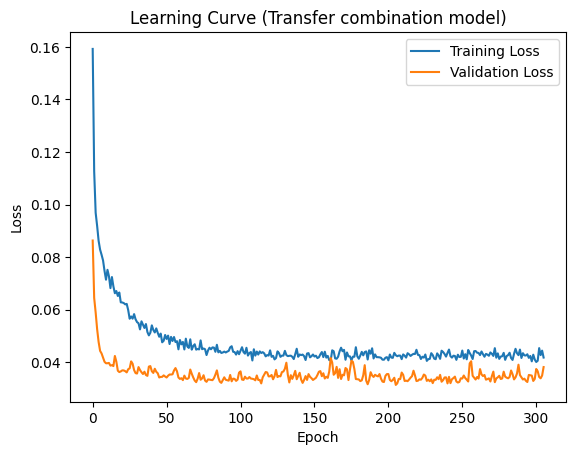

In [24]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Learning Curve (Transfer combination model)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/Transfer_model_combination_learning_curve.svg', bbox_inches = 'tight')
plt.show()

In [25]:
train_loss = history.history['loss'][-1]
train_mae = history.history['mae'][-1]
print(f"Training Loss: {train_loss:.4f}")
print(f"Training MAE: {train_mae:.4f}")

Training Loss: 0.0418
Training MAE: 0.1545


In [26]:
val_loss = history.history['val_loss'][-1]
val_mae = history.history['val_mae'][-1]
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation MAE: {val_mae:.4f}")

Validation Loss: 0.0382
Validation MAE: 0.1430


In [27]:
loss, mae = new_model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test MAE: {mae:.4f}")

Test Loss: 0.0421
Test MAE: 0.1549


In [28]:
predictions = new_model.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 290ms/step


In [29]:
predictions.shape

(44, 218)

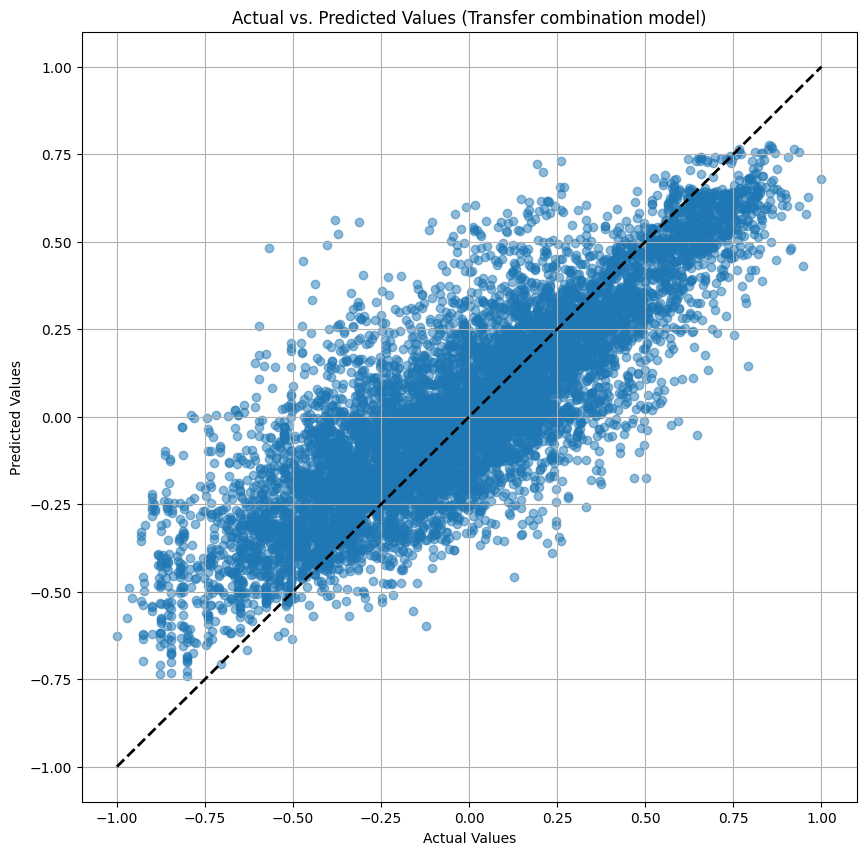

In [30]:
plt.figure(figsize=(10, 10))
plt.scatter(y_test, predictions, alpha=0.5)
plt.plot([y_test.min().min(), y_test.max().max()], [y_test.min().min(), y_test.max().max()], 'k--', lw=2, label='Ideal')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values (Transfer combination model)")
plt.grid(True)
plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/Transfer_combination_model_actual_vs_pred.svg', bbox_inches = 'tight')
plt.show()

In [31]:
from sklearn.metrics import mean_squared_error

def get_metrics(y_predicted):

  mse = mean_squared_error(y_test, y_predicted)
  print("MSE:", mse)

  from sklearn.metrics import mean_absolute_error
  mae = mean_absolute_error(y_test, y_predicted)
  print("MAE:", mae)

  from sklearn.metrics import median_absolute_error
  medae = median_absolute_error(y_test, y_predicted,)
  print("MedAE:", medae)

  def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

  mape = mean_absolute_percentage_error(y_test, y_predicted)
  print('Mean absolute percentage error:', mape)

In [32]:
get_metrics(y_predicted = predictions)

MSE: 0.04214172810316086
MAE: 0.15492531657218933
MedAE: 0.12647595
Mean absolute percentage error: 224.67181


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


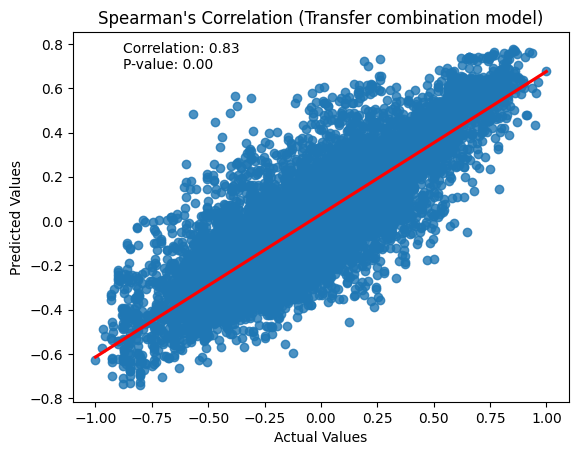

In [33]:
from scipy.stats import spearmanr

def get_spearman_correlation(model_predictions):

  correlation, p_value = spearmanr(X_test, model_predictions)

  correlation_df = pd.DataFrame({'Actual': y_test.flatten(), 'Predicted': model_predictions.flatten()})

  # Calculate Spearman's correlation
  correlation, p_value = spearmanr(correlation_df['Actual'], correlation_df['Predicted'])

  # Add correlation and p-value to DataFrame
  correlation_df['Correlation'] = correlation
  correlation_df['P-value'] = p_value

  sns.regplot(x='Actual', y='Predicted', data=correlation_df, line_kws={'color': 'red'})
  plt.title(f'Spearman\'s Correlation (Transfer combination model)')
  plt.xlabel('Actual Values')
  plt.ylabel('Predicted Values')

  # Add correlation and p-value as text
  plt.text(0.1, 0.9, f'Correlation: {correlation:.2f}\nP-value: {p_value:.2f}', transform=plt.gca().transAxes)
  plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/Transfer_combination_model_spearmans_reg_plot.svg', bbox_inches = 'tight')
  plt.show()


get_spearman_correlation(predictions)

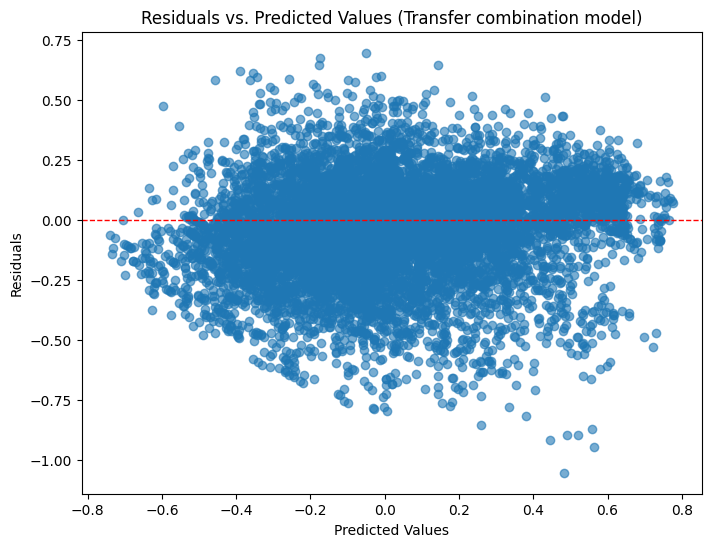

In [34]:
#Checking for heteroscedasticity
!pip install statsmodels

import statsmodels.api as sm

def get_residuals_vs_pred_plot(model_predictions):

  residuals = (y_test - model_predictions).ravel()

  plt.figure(figsize=(8, 6))
  plt.scatter(model_predictions.ravel(), residuals, alpha=0.6)
  plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
  plt.title(f"Residuals vs. Predicted Values (Transfer combination model)")
  plt.xlabel("Predicted Values")
  plt.ylabel("Residuals")
  plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/Transfer_combination_model_residuals.svg', bbox_inches = 'tight')
  plt.show()

get_residuals_vs_pred_plot(predictions)

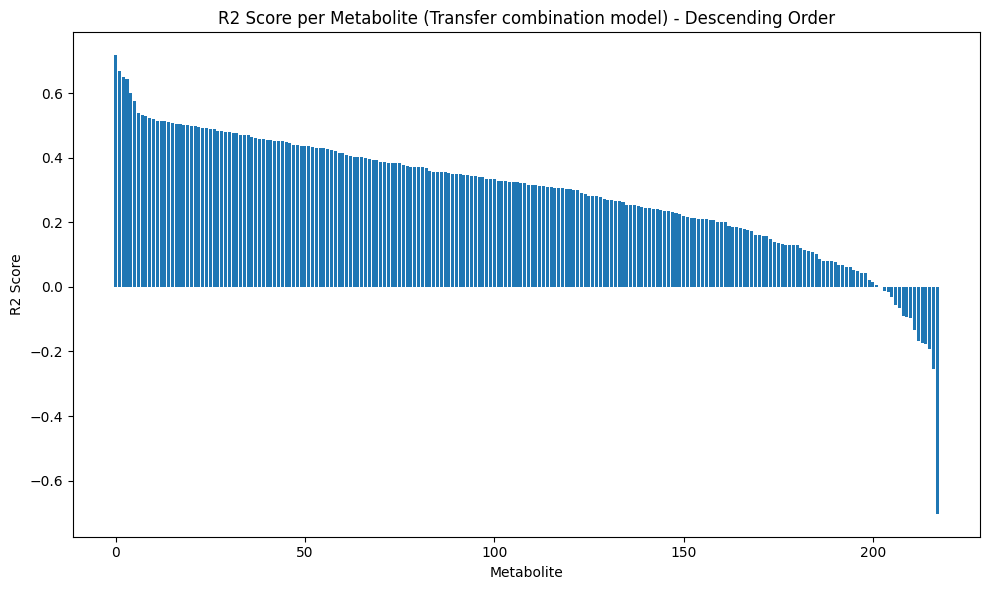

In [35]:
from sklearn.metrics import r2_score

def plot_r2_per_metabolite(y_true, y_pred, metabolite_names):
    """Plots the R2 score per metabolite for a given model in descending order."""

    r2_scores = []  # Initialize list to store R2 scores
    for i in range(y_true.shape[1]):  # Iterate through each metabolite (column)
        # Calculate R2 for the current metabolite across all samples
        r2 = r2_score(y_true[:, i], y_pred[:, i])
        r2_scores.append(r2)  # Add the R2 score to the list

    # Create a DataFrame for sorting
    r2_df = pd.DataFrame({'Metabolite': metabolite_names, 'R2 Score': r2_scores})

    # Sort the DataFrame by R2 scores in descending order
    r2_df = r2_df.sort_values(by=['R2 Score'], ascending=False)
    r2_df.to_csv('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/results/r2_df_transfer_combination.csv', index =True)

    # Plotting
    plt.figure(figsize=(10, 6))  # Adjust figure size as needed
    plt.bar(range(len(r2_df)), r2_df['R2 Score'])  # Create bar plot of R2 scores
    plt.xticks()  # Set x-axis labels to metabolite names
    plt.xlabel("Metabolite")
    plt.ylabel("R2 Score")
    plt.title(f"R2 Score per Metabolite (Transfer combination model) - Descending Order")
    plt.tight_layout()  # Adjust layout to prevent labels from overlapping
    plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/Transfer_combination_model_r2_per_metabolite.svg', bbox_inches = 'tight')
    plt.show()

# Get the original metabolite names before splitting and normalization
original_metabolite_names = metabolites.columns

# Call the function with y_test, predictions, and original_metabolite_names
plot_r2_per_metabolite(y_test, predictions, original_metabolite_names)

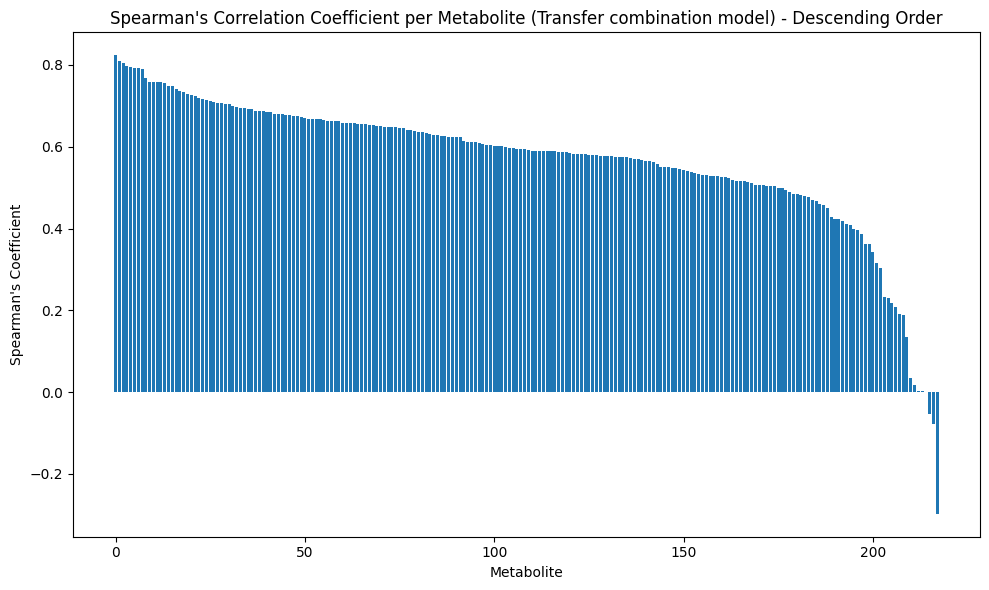

In [36]:
def plot_spearman_per_metabolite(y_true, y_pred, metabolite_names):
    """Plots the Spearman's correlation coefficient per metabolite for a given model."""

    spearman_coeffs = []  # Initialize list to store Spearman's coefficients
    for i in range(y_true.shape[1]):  # Iterate through each metabolite (column)
        # Ensure y_true and y_pred for the current metabolite are 1D arrays
        coeff, _ = spearmanr(y_true[:, i].ravel(), y_pred[:, i].ravel())  # Calculate Spearman's coefficient
        spearman_coeffs.append(coeff)  # Add the coefficient to the list

    # Create a DataFrame for sorting using metabolite names
    spearman_df = pd.DataFrame({'Metabolite': metabolite_names, 'Spearman Coefficient': spearman_coeffs})

    # Sort the DataFrame by Spearman's coefficients in descending order
    spearman_df = spearman_df.sort_values(by=['Spearman Coefficient'], ascending=False)
    spearman_df.to_csv('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/results/spearman_df_transfer_combination.csv', index =True)

    # Plotting
    plt.figure(figsize=(10, 6))  # Adjust figure size as needed
    # Use the metabolite names from the sorted DataFrame for x-axis labels
    plt.bar(range(len(spearman_df)), spearman_df['Spearman Coefficient'])  # Create bar plot of coefficients
    plt.xticks()  # Set x-axis labels to metabolite names and rotate them
    plt.xlabel("Metabolite")
    plt.ylabel("Spearman's Coefficient")
    plt.title(f"Spearman's Correlation Coefficient per Metabolite (Transfer combination model) - Descending Order")
    plt.tight_layout()  # Adjust layout to prevent labels from overlapping
    plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/Transfer_combination_model_spearmans_per_metabolite.svg', bbox_inches = 'tight')
    plt.show()

original_metabolite_names = metabolites.columns

# Call the function with y_test, predictions, and original_metabolite_names
plot_spearman_per_metabolite(y_test, predictions, original_metabolite_names)